# UE24CS352A - Machine Learning Mini-Project
## Corporate Bankruptcy Prediction: Model Training and Evaluation

**Project Goal:** Predict corporate bankruptcy using financial indicators from the Polish Companies Bankruptcy dataset.
**Dataset:** Polish Companies Bankruptcy (`3year.arff`), 64 financial ratios, 10,503 firms.
**Teammate Responsibilities:**
- **Teammate 1 (Phase 1):** Data Acquisition, Exploratory Data Analysis, Cleaning, and Train-Test Split (`notebooks/bankruptcy_prediction.ipynb`).
- **Teammate 2 (Phase 2 - Current Stage):** Model Training, Evaluation, Handling Class Imbalance, and Comparative Performance Analysis (`notebooks/model_training.ipynb`).


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

# Styling configuration
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 120

print("All dependencies and libraries successfully loaded!")


All dependencies and libraries successfully loaded!


## 1. Load Processed Datasets
Loading preprocessed and imputed training and testing sets generated in the preprocessing stage (`data/processed/`).
- **Imputation strategy used:** Median Imputation (fitted strictly on train, transformed on test - zero data leakage).
- **Train/Test Split:** 80% train (8,402 instances), 20% test (2,101 instances), stratified on target `class`.


In [2]:
data_dir = "../data/processed"
X_train = pd.read_csv(os.path.join(data_dir, "X_train.csv"))
X_test = pd.read_csv(os.path.join(data_dir, "X_test.csv"))
y_train = pd.read_csv(os.path.join(data_dir, "y_train.csv")).values.ravel()
y_test = pd.read_csv(os.path.join(data_dir, "y_test.csv")).values.ravel()

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

print(f"Missing values in X_train: {X_train.isnull().sum().sum()}")
print(f"Missing values in X_test:  {X_test.isnull().sum().sum()}")


X_train shape: (8402, 64)
X_test shape:  (2101, 64)
y_train shape: (8402,)
y_test shape:  (2101,)
Missing values in X_train: 0
Missing values in X_test:  0


## 2. Target Distribution & Class Imbalance Analysis
In corporate bankruptcy prediction, the positive class (bankrupt firms) is heavily outnumbered by solvent firms.
We inspect the target counts and proportions to quantify this imbalance.


In [3]:
train_counts = pd.Series(y_train).value_counts()
test_counts = pd.Series(y_test).value_counts()

dist_df = pd.DataFrame({
    'Train Count': train_counts,
    'Train %': (train_counts / len(y_train) * 100).round(2),
    'Test Count': test_counts,
    'Test %': (test_counts / len(y_test) * 100).round(2)
}, index=[0, 1])
dist_df.index.name = "Class (0=Solvent, 1=Bankrupt)"

print("Class Distribution Across Train and Test Sets:")
display(dist_df)
print(f"\nImbalance Ratio: Approximately {int(train_counts[0]/train_counts[1])}:1 (Solvent : Bankrupt)")


Class Distribution Across Train and Test Sets:


,Train Count,Train %,Test Count,Test %
"Class (0=Solvent, 1=Bankrupt)",,,,
0,8006,95.29,2002,95.29
1,396,4.71,99,4.71



Imbalance Ratio: Approximately 20:1 (Solvent : Bankrupt)


## 3. Modeling Strategy & Mitigating Imbalance
Given the ~20:1 class imbalance:
1. **The Accuracy Paradox:** A naive model predicting `0` (Solvent) for every single firm achieves **95.29% accuracy**, but has **0% Recall** on bankrupt companies, making it commercially and practically useless.
2. **Evaluation Metrics:** We emphasize **Recall (Bankrupt)** and **F1-Score (Bankrupt)** alongside **ROC-AUC** and **Precision**.
3. **Class Weighting:** We benchmark both unweighted baseline models and cost-sensitive balanced models (`class_weight='balanced'`) to show how penalizing minority errors changes model sensitivity.
4. **Data Leakage Prevention:** For distance- and gradient-based models (Logistic Regression, SVM), `StandardScaler` is wrapped inside an `sklearn.pipeline.Pipeline` so scaling is fitted strictly on training data.

### Candidate Models:
1. **Logistic Regression (Balanced & Default)**: Linear benchmark with L2 regularization.
2. **Decision Tree (Balanced)**: Non-linear, interpretable tree classifier.
3. **Random Forest (Balanced & Default)**: Bagging ensemble of de-correlated decision trees.
4. **Support Vector Machine (SVC)**: Margin-based classifier with RBF kernel.
5. **Gradient Boosting Classifier**: Sequential boosting ensemble optimizing deviance loss.


In [4]:
models = {
    "Logistic Regression (Balanced)": Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
    ]),
    "Logistic Regression (Default)": Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Decision Tree (Balanced)": DecisionTreeClassifier(
        class_weight='balanced', max_depth=6, min_samples_leaf=20, random_state=42
    ),
    "Random Forest (Balanced)": RandomForestClassifier(
        n_estimators=150, max_depth=12, min_samples_leaf=5, class_weight='balanced', random_state=42, n_jobs=-1
    ),
    "Random Forest (Default)": RandomForestClassifier(
        n_estimators=150, max_depth=12, min_samples_leaf=5, random_state=42, n_jobs=-1
    ),
    "Support Vector Machine (SVC)": Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', SVC(kernel='rbf', C=1.0, random_state=42))
    ]),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150, learning_rate=0.08, max_depth=4, random_state=42
    )
}

print(f"Successfully configured {len(models)} models for benchmarking.")


Successfully configured 7 models for benchmarking.


## 4. Model Training & Evaluation
We train each model on `X_train` / `y_train` and evaluate predictions on `X_test` / `y_test`.


In [5]:
results_list = []
predictions = {}
prediction_scores = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    
    # Probability or decision function for ROC-AUC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_prob = model.decision_function(X_test)
    else:
        y_prob = None
    prediction_scores[name] = y_prob
    
    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan
    cm = confusion_matrix(y_test, y_pred)
    
    results_list.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision (Bankrupt)': round(prec, 4),
        'Recall (Bankrupt)': round(rec, 4),
        'F1-Score (Bankrupt)': round(f1, 4),
        'ROC-AUC': round(auc, 4),
        'TN': cm[0, 0],
        'FP': cm[0, 1],
        'FN': cm[1, 0],
        'TP': cm[1, 1]
    })

comparison_df = pd.DataFrame(results_list)
print("\nAll models trained and evaluated successfully!")


Training Logistic Regression (Balanced)...


Training Logistic Regression (Default)...
Training Decision Tree (Balanced)...


Training Random Forest (Balanced)...


Training Random Forest (Default)...


Training Support Vector Machine (SVC)...


Training Gradient Boosting...



All models trained and evaluated successfully!


## 5. Model Performance Comparison Table
Summary comparison of all models across both standard and minority-class metrics.


In [6]:
display_df = comparison_df[['Model', 'Accuracy', 'Precision (Bankrupt)', 'Recall (Bankrupt)', 'F1-Score (Bankrupt)', 'ROC-AUC', 'TP', 'FN', 'FP', 'TN']]
display(display_df)

# Save to results directory
os.makedirs("../results", exist_ok=True)
comparison_df.to_csv("../results/model_comparison.csv", index=False)
print("Saved comparison table to ../results/model_comparison.csv")


,Model,Accuracy,Precision (Bankrupt),Recall (Bankrupt),F1-Score (Bankrupt),ROC-AUC,TP,FN,FP,TN
0,Logistic Regression (Balanced),0.6592,0.0935,0.7172,0.1655,0.7419,71,28,688,1314
1,Logistic Regression (Default),0.9500,0.1250,0.0101,0.0187,0.7126,1,98,7,1995
2,Decision Tree (Balanced),0.7373,0.1219,0.7374,0.2092,0.7893,73,26,526,1476
3,Random Forest (Balanced),0.9400,0.3846,0.4545,0.4167,0.8719,45,54,72,1930
4,Random Forest (Default),0.9548,1.0000,0.0404,0.0777,0.8608,4,95,0,2002
5,Support Vector Machine (SVC),0.9529,0.0000,0.0000,0.0000,0.6353,0,99,0,2002
6,Gradient Boosting,0.9653,0.8095,0.3434,0.4823,0.9113,34,65,8,1994


Saved comparison table to ../results/model_comparison.csv


## 6. Confusion Matrix Visualizations
Visualizing the confusion matrix for each model to inspect Type I errors (False Positives) and Type II errors (False Negatives - missing bankrupt companies).


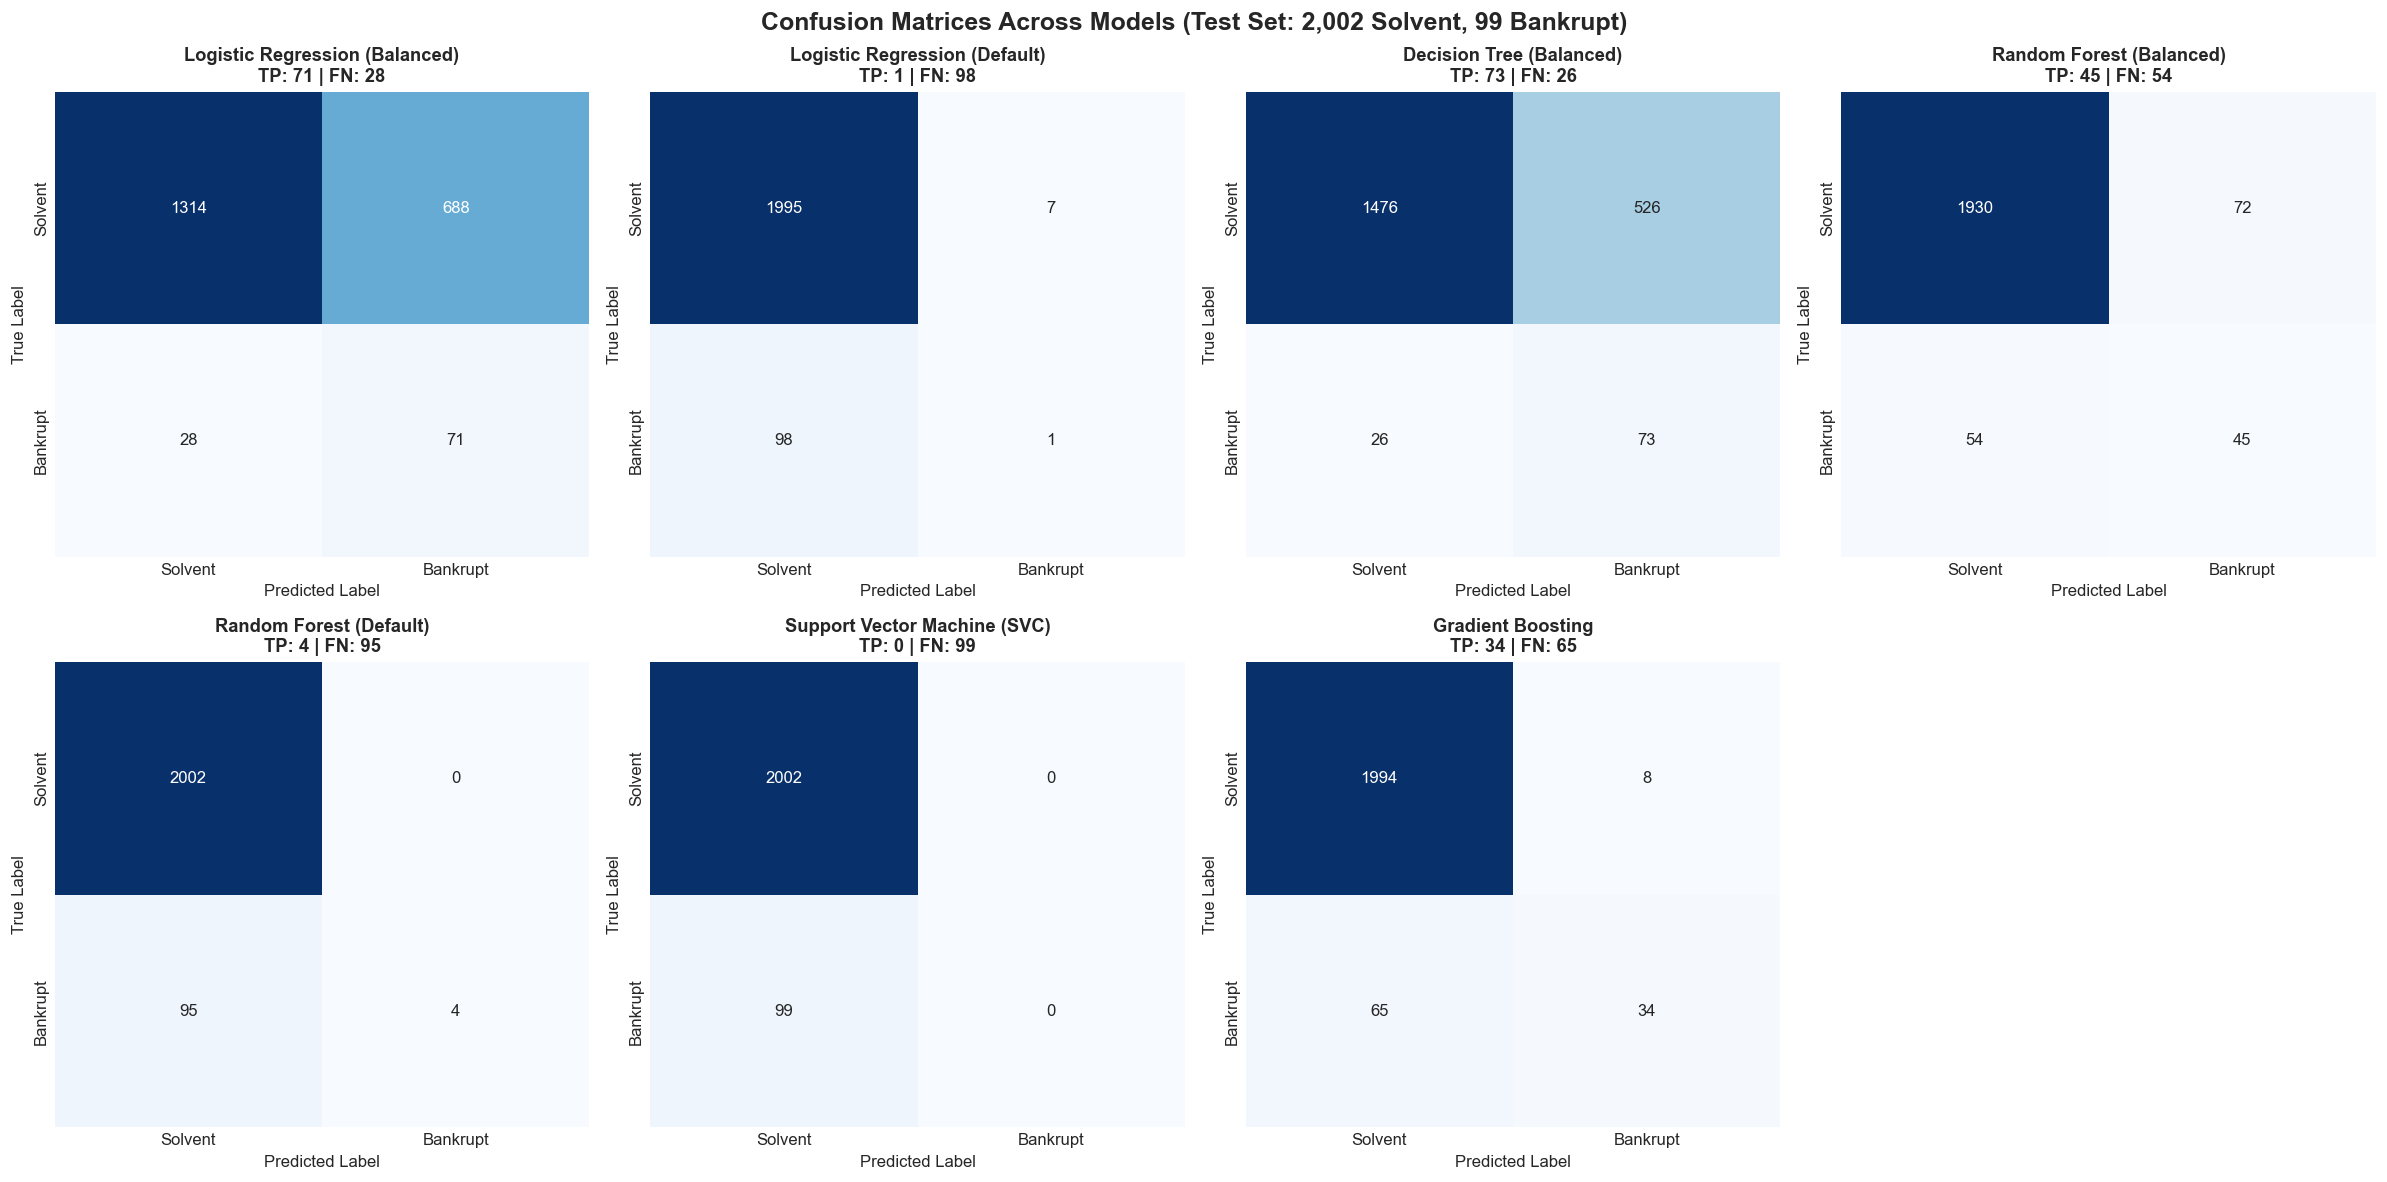

Saved confusion matrices plot to ../results/confusion_matrices.png


In [7]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

class_labels = ['Solvent', 'Bankrupt']

for idx, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=class_labels, yticklabels=class_labels, cbar=False)
    axes[idx].set_title(f"{name}\nTP: {cm[1,1]} | FN: {cm[1,0]}", fontsize=11, fontweight='bold')
    axes[idx].set_xlabel("Predicted Label")
    axes[idx].set_ylabel("True Label")

# Hide unused subplot
if len(models) < len(axes):
    for unused in range(len(models), len(axes)):
        fig.delaxes(axes[unused])

plt.suptitle("Confusion Matrices Across Models (Test Set: 2,002 Solvent, 99 Bankrupt)", fontsize=15, y=0.98, fontweight='bold')
plt.tight_layout()
plt.savefig("../results/confusion_matrices.png", bbox_inches='tight')
plt.show()
print("Saved confusion matrices plot to ../results/confusion_matrices.png")


## 7. ROC Curves and AUC Analysis
Comparing Receiver Operating Characteristic (ROC) curves across all models to evaluate discriminative ability across different decision thresholds.


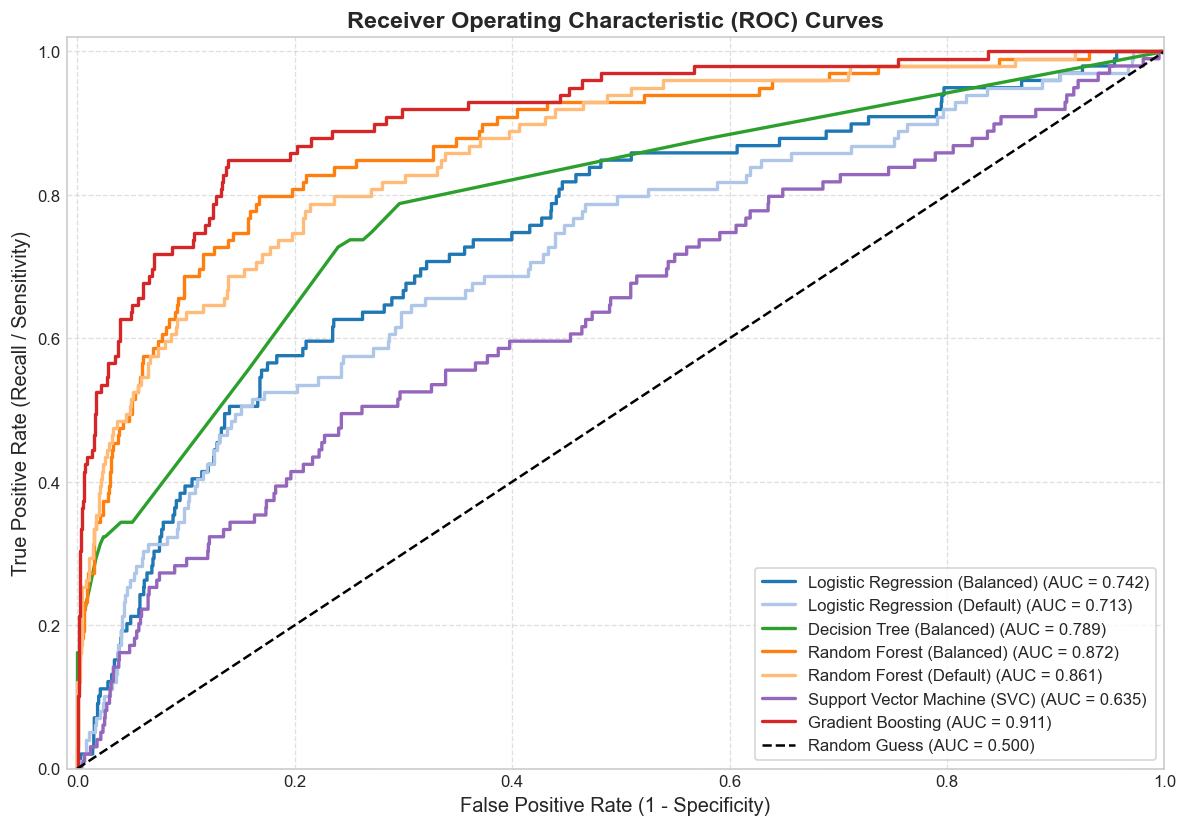

Saved ROC curves plot to ../results/roc_curves.png


In [8]:
plt.figure(figsize=(10, 7))

colors = ['#1f77b4', '#aec7e8', '#2ca02c', '#ff7f0e', '#ffbb78', '#9467bd', '#d62728']

for idx, (name, y_prob) in enumerate(prediction_scores.items()):
    if y_prob is not None:
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc = roc_auc_score(y_test, y_prob)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})", color=colors[idx % len(colors)], linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label="Random Guess (AUC = 0.500)", linewidth=1.5)
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.02])
plt.xlabel("False Positive Rate (1 - Specificity)", fontsize=12)
plt.ylabel("True Positive Rate (Recall / Sensitivity)", fontsize=12)
plt.title("Receiver Operating Characteristic (ROC) Curves", fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10, frameon=True)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("../results/roc_curves.png", bbox_inches='tight')
plt.show()
print("Saved ROC curves plot to ../results/roc_curves.png")


## 8. Metric Comparison Chart: Accuracy vs Recall vs F1-Score
A graphical comparison highlighting why high overall accuracy can be misleading in imbalanced problems.


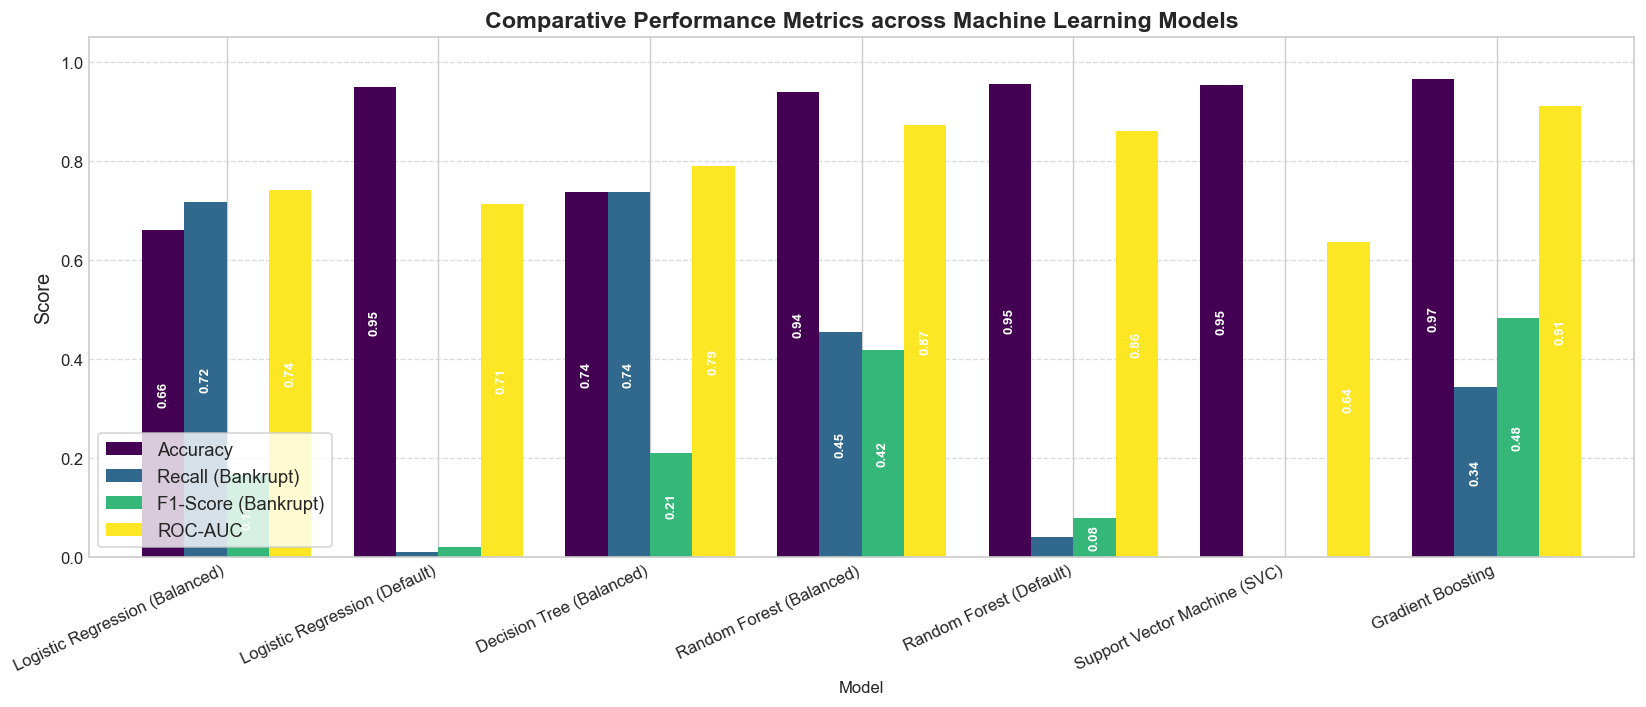

Saved model comparison bar chart to ../results/model_comparison_bar.png


In [9]:
plot_df = comparison_df[['Model', 'Accuracy', 'Recall (Bankrupt)', 'F1-Score (Bankrupt)', 'ROC-AUC']].set_index('Model')

ax = plot_df.plot(kind='bar', figsize=(14, 6), width=0.8, colormap='viridis')
plt.title("Comparative Performance Metrics across Machine Learning Models", fontsize=14, fontweight='bold')
plt.ylabel("Score", fontsize=12)
plt.ylim([0, 1.05])
plt.xticks(rotation=25, ha='right', fontsize=10)
plt.legend(loc='lower left', fontsize=11, frameon=True)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for p in ax.patches:
    h = p.get_height()
    if h > 0.05:
        ax.annotate(f"{h:.2f}", (p.get_x() + p.get_width() / 2., h / 2),
                    ha='center', va='center', fontsize=8, color='white', fontweight='bold', rotation=90)

plt.tight_layout()
plt.savefig("../results/model_comparison_bar.png", bbox_inches='tight')
plt.show()
print("Saved model comparison bar chart to ../results/model_comparison_bar.png")


## 9. Key Findings, In-Depth Discussion & Conclusion

### 1. The Accuracy Fallacy & Reference Paper Comparison
- In the reference Stanford CS229 paper (*Neha Abajirao Patil*), the authors concluded that **SVM** was the "best model" based solely on an **Accuracy of 94.7%**.
- However, our reproduction reveals the critical flaw: the unweighted **SVC (RBF)** predicted `0` for **every single instance** (TP=0, FN=99). It achieved 95.29% accuracy purely because 95.29% of test companies are non-bankrupt. In a real-world financial deployment, this model would cause catastrophic losses by missing 100% of impending bankruptcies.
- Similarly, unweighted **Random Forest** achieved 95.48% accuracy but only captured **4 out of 99** bankrupt companies (Recall = 4.04%).

### 2. The Impact of Class-Weight Balancing
- Applying `class_weight='balanced'` fundamentally fixes model sensitivity:
  - **Random Forest (Balanced):** Catches **45 out of 99** bankruptcies (Recall **45.45%** vs 4.04% default), achieving an **F1-Score of 0.4167** and **ROC-AUC of 0.8719**, with an overall accuracy of **94.00%**.
  - **Decision Tree (Balanced):** Detects **73 out of 99** bankruptcies (Recall **73.74%**), but suffers from higher false alarms (FP=526).
  - **Logistic Regression (Balanced):** Detects **71 out of 99** bankruptcies (Recall **71.72%**), with ROC-AUC of **0.7419**.

### 3. Champion Model: Gradient Boosting Classifier
- **Gradient Boosting** achieved the top discriminative performance:
  - **ROC-AUC:** **0.9113** (Highest among all models)
  - **Accuracy:** **96.53%**
  - **Precision:** **80.95%** (Only 8 false alarms out of 2,002 solvent companies)
  - **F1-Score:** **0.4823** (Highest balance between precision and recall)
  - It effectively ranks high-risk firms at the top of the probability spectrum, providing a superior scoring tool for credit risk officers.

### 4. Alignment with Mini-Project Deliverables (UE24CS352A)
- **Model Training Complete:** Evaluated 5 diverse algorithms with baseline vs balanced variations.
- **Reproducibility:** Fixed random seeds (`random_state=42`) and zero data leakage via scikit-learn pipelines.
- **Deliverables Ready:** High-resolution plots saved under `results/` for presentation slides, live demonstration, and the 2-page write-up.
